# Workflows

(Default) Podcast: StreamCast
* 10-minute video output given a PDF and a text prompt

Other multimodal workflows:

1) Shorts
2) Movie
3) Animated story
4) Lecture
5) Slide persona
6) Dubbing
7) Editing
8) Video chat

## Requirements

In [1]:
from __future__ import annotations

import os
import pandas as pd

from constants import SECONDS_IN_HOUR

from sim_types import ProvisioningResult
from sim_types import num_gpus_to_str

from data_loading import load_latency_data
from data_loading import load_power_data

from utils import to_models_df
from utils import find_most_cost_effective_provisioning
from utils import find_fastest_provisioning

from plot_utils import plot_ttff_vs_cost
from plot_utils import plot_policies_ttff_vs_cost

from workflows import PODCAST_WORKFLOW
from workflows import SHORTS_WORKFLOW
from workflows import MOVIE_WORKFLOW
from workflows import ANIMATED_STORY_WORKFLOW
from workflows import LECTURE_WORKFLOW
from workflows import SLIDE_PERSONA_WORKFLOW
from workflows import DUBBING_WORKFLOW
from workflows import EDITING_WORKFLOW
from workflows import VIDEO_CHAT_WORKFLOW

from provisioning import get_provisioning_results

from policies import STREAMWISE_POLICY
from policies import NAIVE_POLICY

In [2]:
data_dir = "data/"
results_dir = "results/"

SHORT_LIST = True

In [3]:
os.makedirs(results_dir, exist_ok=True)

In [4]:
def print_provisioning_result(
    provisioning_result: ProvisioningResult,
    idx: int,
) -> pd.DataFrame:
    latency = provisioning_result.latencies[idx]
    cost = provisioning_result.costs[idx]
    energy = provisioning_result.energies[idx]
    provision = provisioning_result.actual_provision[idx]
    models = provisioning_result.model_provision[idx]
    print(f"{latency:.1f} seconds, ${cost:.1f}, {energy:.1f} Ws: {num_gpus_to_str(provision)}")
    return to_models_df(models)

In [5]:
latency_data = load_latency_data(data_dir=data_dir)
power_data = load_power_data(data_dir=data_dir)

In [6]:
policies = {
    "Naive": NAIVE_POLICY,
    "StreamWise": STREAMWISE_POLICY,
}

provisioning_results: dict[str, dict[str, ProvisioningResult]] = {}
for policy_name in policies.keys():
    provisioning_results[policy_name] = {}

## Podcast

In [7]:
for policy_name, policy in policies.items():
    provisioning_results[policy_name]["podcast"] = get_provisioning_results(
        workflow=PODCAST_WORKFLOW,
        latency_data=latency_data,
        power_data=power_data,
        policy=policy,
        short_list=SHORT_LIST,
    )

naive policy:   0%|          | 0/16 [00:00<?, ?it/s]

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

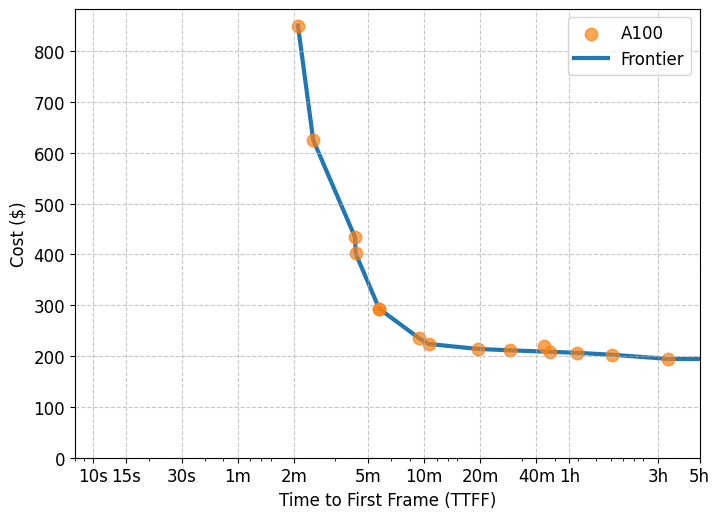

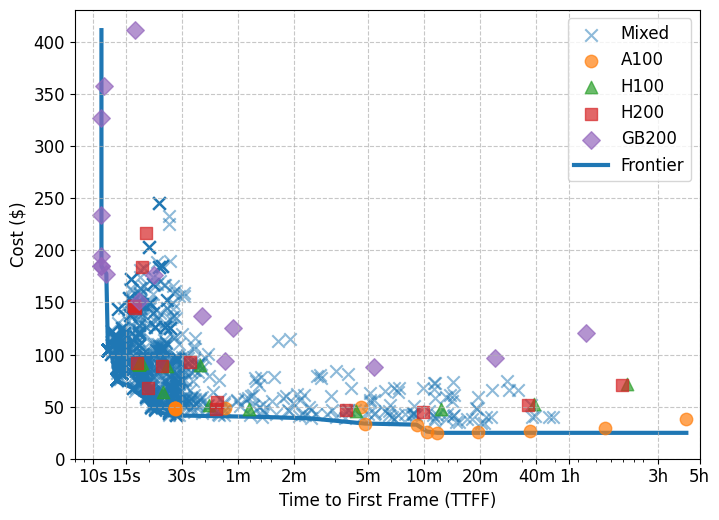

In [8]:
for policy_name in policies.keys():
    plot_ttff_vs_cost(
        ttffs=provisioning_results[policy_name]["podcast"].ttffs,
        costs=provisioning_results[policy_name]["podcast"].costs,
        provisions=provisioning_results[policy_name]["podcast"].actual_provision,
        xmin=8,  # 8 seconds
        xmax=5 * SECONDS_IN_HOUR,  # 5 hours
    )

## Shorts

For a workflow that generates shorts: 2 hour video input → 10 second highlight from selected frames

- Podcast base; no image; no video
- Input: 2 hours 3600 seconds/hour 1 frame/second * 500 tokens/frame = 3,600,000 tokens
- Output: 10 seconds * 30 FPS = 300 frames = 300 tokens
    - LLM decides which frames to include in the final short
    - Treat as: 10 scenes (10 seconds), each scene has 30 decode steps (30 frames)

In [9]:
for policy_name, policy in policies.items():
    provisioning_results[policy_name]["short"] = get_provisioning_results(
        workflow=SHORTS_WORKFLOW,
        latency_data=latency_data,
        power_data=power_data,
        policy=policy,
        short_list=True,
    )

naive policy:   0%|          | 0/16 [00:00<?, ?it/s]

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

In [10]:
result_idx = find_most_cost_effective_provisioning(provisioning_results["StreamWise"]["short"])
print_provisioning_result(provisioning_results["StreamWise"]["short"], result_idx)

210.6 seconds, $151.1, 141231719.4 Ws: 235xGB200


Devices  Replicas  Work  #GPUs  Time (s)  TTFF (s)  \
GB200 gemma         1       202     0    202    100.01    239.94   
      gemma         8         4     0     32    138.65     81.56   
      others        1         1     0      1     72.00      0.10   
TOTAL              10       207     0    235    210.65     81.66   

              Energy (kWh)  Cost ($)  
GB200 gemma           1.09    127.18  
      gemma          38.14     20.15  
      others          0.00      0.63  
TOTAL                39.23    147.96

In [11]:
result_idx = find_fastest_provisioning(provisioning_results["StreamWise"]["short"])
print_provisioning_result(provisioning_results["StreamWise"]["short"], result_idx)

210.6 seconds, $151.1, 141231719.4 Ws: 235xGB200


Devices  Replicas  Work  #GPUs  Time (s)  TTFF (s)  \
GB200 gemma         1       202     0    202    100.01    239.94   
      gemma         8         4     0     32    138.65     81.56   
      others        1         1     0      1     72.00      0.10   
TOTAL              10       207     0    235    210.65     81.66   

              Energy (kWh)  Cost ($)  
GB200 gemma           1.09    127.18  
      gemma          38.14     20.15  
      others          0.00      0.63  
TOTAL                39.23    147.96

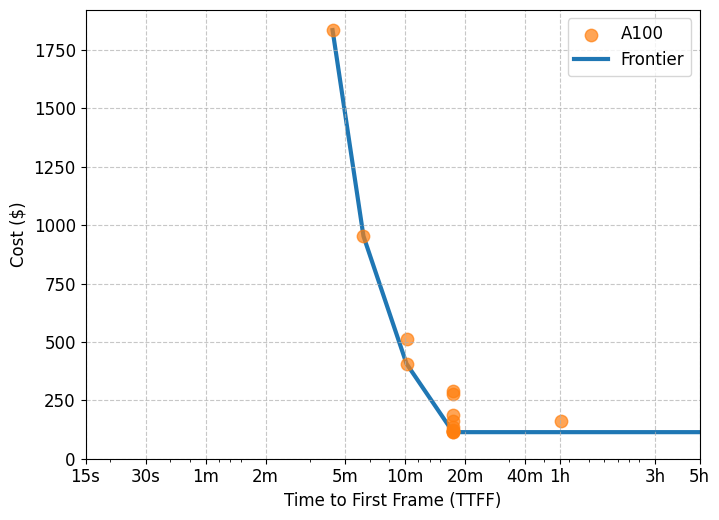

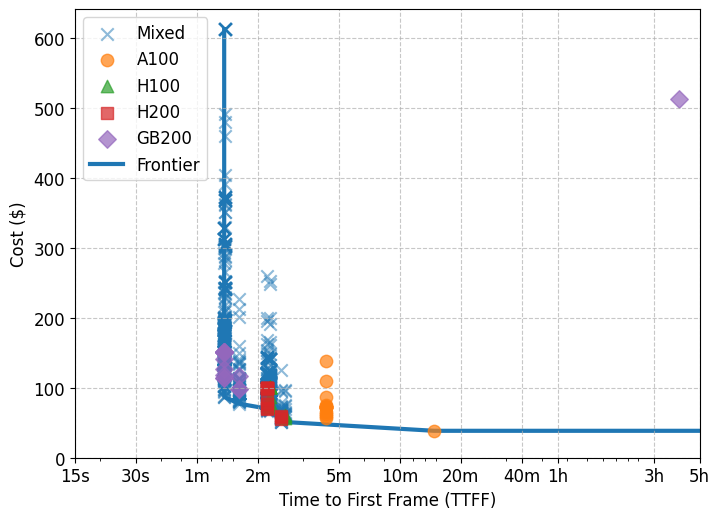

In [12]:
for policy_name in policies.keys():
    plot_ttff_vs_cost(
        ttffs=provisioning_results[policy_name]["short"].ttffs,
        costs=provisioning_results[policy_name]["short"].costs,
        provisions=provisioning_results[policy_name]["short"].actual_provision,
        # ymax=220,
        xmin=15,  # 15 seconds
        xmax=5 * SECONDS_IN_HOUR,  # 5 hours
    )

## Movie

For a workflow that generates a 2-hour movie out of text and image inputs:
- Podcast base
- 2-hour video output
- 1 image per scene generated using Flux

In [13]:
for policy_name, policy in policies.items():
    provisioning_results[policy_name]["movie"] = get_provisioning_results(
        workflow=MOVIE_WORKFLOW,
        latency_data=latency_data,
        power_data=power_data,
        policy=policy,
        short_list=SHORT_LIST,
    )

naive policy:   0%|          | 0/16 [00:00<?, ?it/s]

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

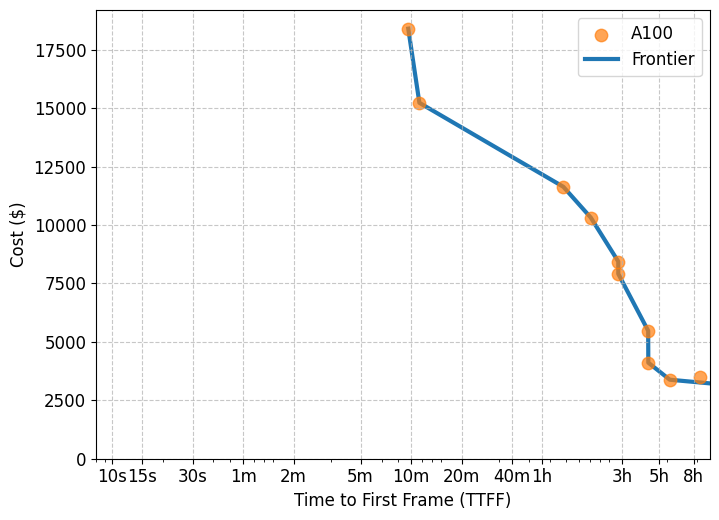

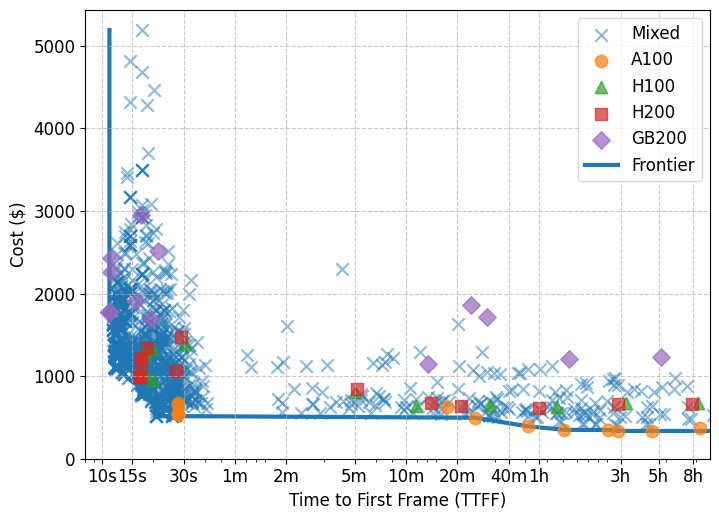

In [14]:
for policy_name in policies.keys():
    plot_ttff_vs_cost(
        ttffs=provisioning_results[policy_name]["movie"].ttffs,
        costs=provisioning_results[policy_name]["movie"].costs,
        provisions=provisioning_results[policy_name]["movie"].actual_provision,
        # ymax=220,
        xmin=8,  # 8 seconds
        xmax=10 * SECONDS_IN_HOUR,  # 10 hours
    )

## Animated Story

- Podcast base
- LoRA for style adds around 5\% time to video

In [15]:
for policy_name, policy in policies.items():
    provisioning_results[policy_name]["story"] = get_provisioning_results(
        workflow=ANIMATED_STORY_WORKFLOW,
        latency_data=latency_data,
        power_data=power_data,
        policy=policy,
        short_list=SHORT_LIST,
    )

naive policy:   0%|          | 0/16 [00:00<?, ?it/s]

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

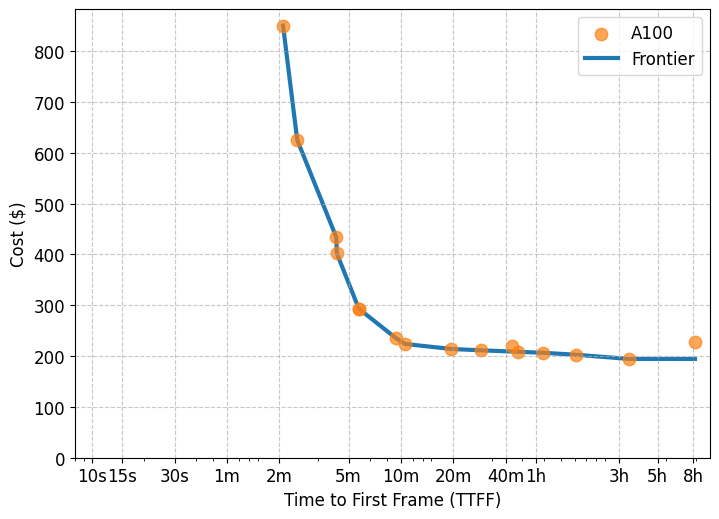

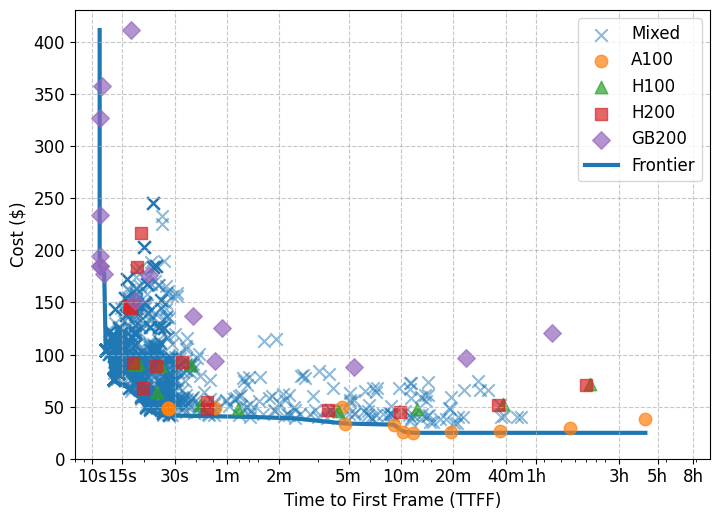

In [16]:
for policy_name in policies.keys():
    plot_ttff_vs_cost(
        ttffs=provisioning_results[policy_name]["story"].ttffs,
        costs=provisioning_results[policy_name]["story"].costs,
        provisions=provisioning_results[policy_name]["story"].actual_provision,
        # ymax=220,
        xmin=8,  # 8 seconds
        xmax=10 * SECONDS_IN_HOUR,  # 10 hours
    )

## Lecture

- Podcast base
- Half of the videos as we replace the others with images from the text

In [17]:
for policy_name, policy in policies.items():
    provisioning_results[policy_name]["lecture"] = get_provisioning_results(
        workflow=LECTURE_WORKFLOW,
        latency_data=latency_data,
        power_data=power_data,
        policy=policy,
        short_list=SHORT_LIST,
    )

naive policy:   0%|          | 0/16 [00:00<?, ?it/s]

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

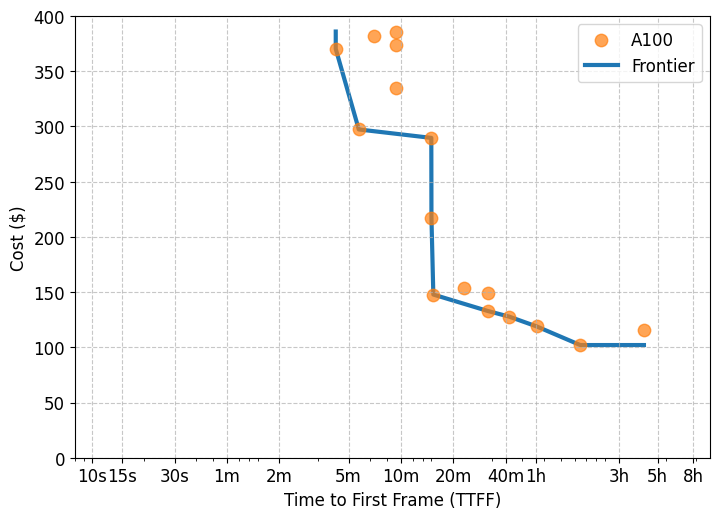

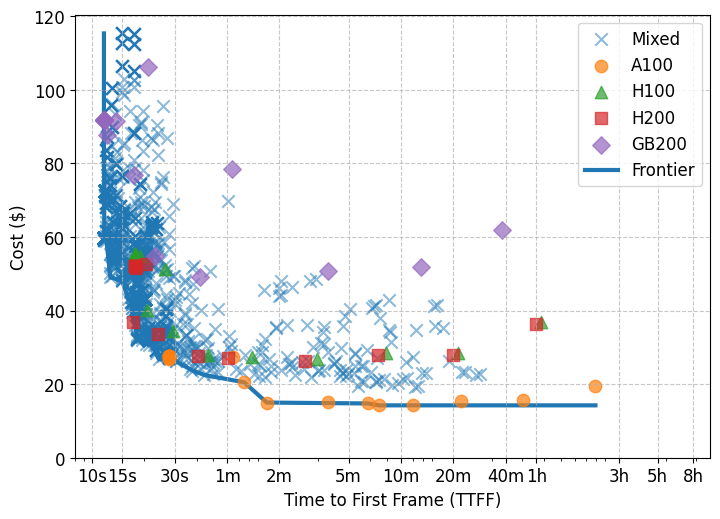

In [18]:
for policy_name in policies.keys():
    plot_ttff_vs_cost(
        ttffs=provisioning_results[policy_name]["lecture"].ttffs,
        costs=provisioning_results[policy_name]["lecture"].costs,
        provisions=provisioning_results[policy_name]["lecture"].actual_provision,
        xmin=8,  # 8 seconds
        xmax=10 * SECONDS_IN_HOUR,  # 10 hours
    )

## Slide Persona
- Podcast base
- 1/4 resolution (1280x800 -> 320x200)

In [19]:
for policy_name, policy in policies.items():
    provisioning_results[policy_name]["slide"] = get_provisioning_results(
        workflow=SLIDE_PERSONA_WORKFLOW,
        latency_data=latency_data,
        power_data=power_data,
        policy=policy,
        short_list=SHORT_LIST,
    )

naive policy:   0%|          | 0/16 [00:00<?, ?it/s]

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

Policy: Naive


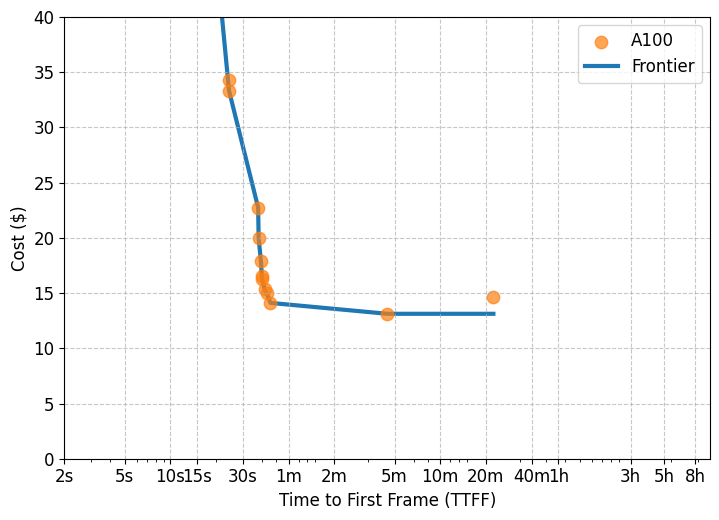

Policy: StreamWise


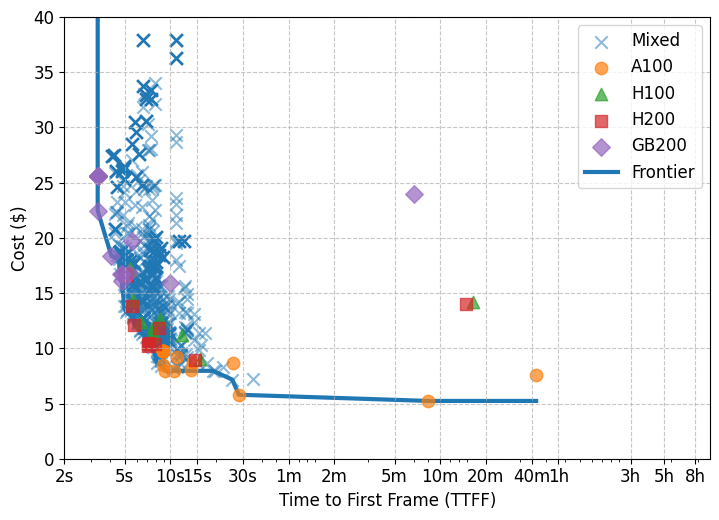

In [20]:
for policy_name in policies.keys():
    print(f"Policy: {policy_name}")
    plot_ttff_vs_cost(
        ttffs=provisioning_results[policy_name]["slide"].ttffs,
        costs=provisioning_results[policy_name]["slide"].costs,
        provisions=provisioning_results[policy_name]["slide"].actual_provision,
        xmin=2,  # 8 seconds
        xmax=10 * SECONDS_IN_HOUR,  # 10 hours
        ymax=40
    )

## Dubbing

- Podcast base
- 2xAudio
- No image/Flux

In [21]:
for policy_name, policy in policies.items():
    provisioning_results[policy_name]["dubbing"] = get_provisioning_results(
        workflow=DUBBING_WORKFLOW,
        latency_data=latency_data,
        power_data=power_data,
        policy=policy,
        short_list=SHORT_LIST,
    )

naive policy:   0%|          | 0/16 [00:00<?, ?it/s]

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

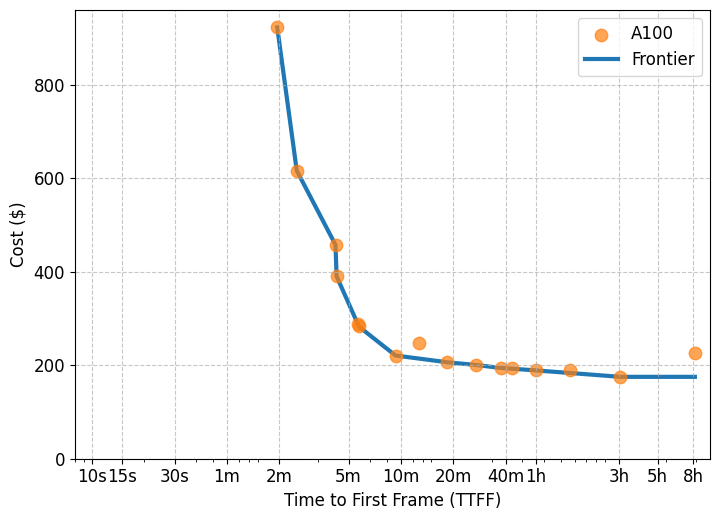

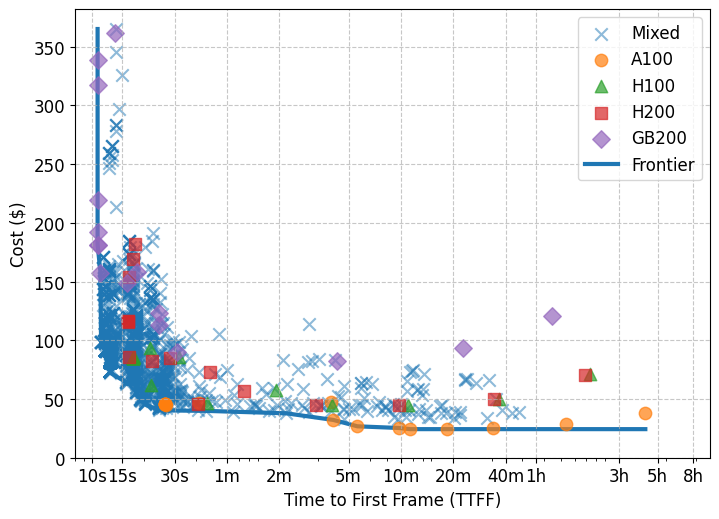

In [22]:
for policy_name in policies.keys():
    plot_ttff_vs_cost(
        ttffs=provisioning_results[policy_name]["dubbing"].ttffs,
        costs=provisioning_results[policy_name]["dubbing"].costs,
        provisions=provisioning_results[policy_name]["dubbing"].actual_provision,
        # ymax=220,
        xmin=8,  # 8 seconds
        xmax=10 * SECONDS_IN_HOUR  # 10 hours
    )

## Editing

- Podcast base
- No LLM/Gemma
- No audio/others
- No image/Flux
- Only video-to-video edit

In [23]:
for policy_name, policy in policies.items():
    provisioning_results[policy_name]["editing"] = get_provisioning_results(
        workflow=EDITING_WORKFLOW,
        latency_data=latency_data,
        power_data=power_data,
        policy=policy,
        short_list=SHORT_LIST,
    )

naive policy:   0%|          | 0/16 [00:00<?, ?it/s]

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

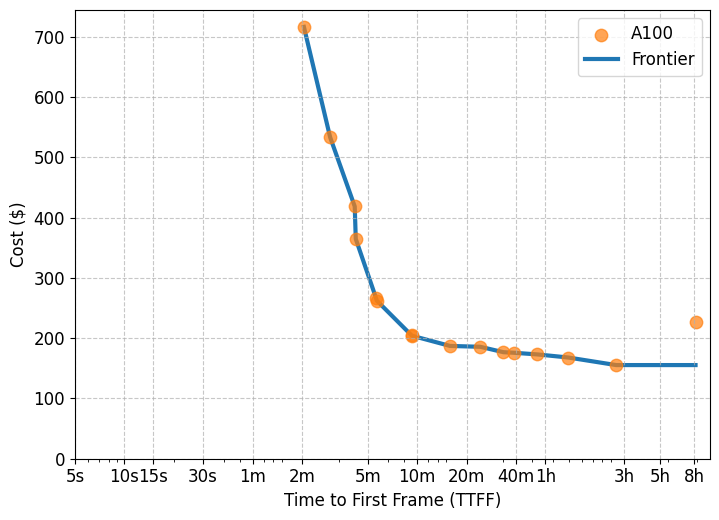

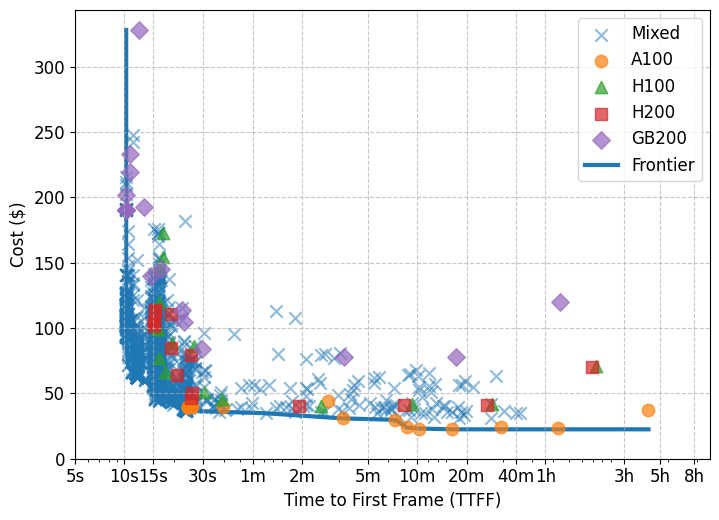

In [24]:
for policy_name in policies.keys():
    plot_ttff_vs_cost(
        ttffs=provisioning_results[policy_name]["editing"].ttffs,
        costs=provisioning_results[policy_name]["editing"].costs,
        provisions=provisioning_results[policy_name]["editing"].actual_provision,
        xmin=5,  # 5 seconds
        xmax=10 * 60 * 60,  # 10 hours
    )

## Video Chat

- Podcast base
- 5 seconds output

In [25]:
for policy_name in policies.keys():
    provisioning_results[policy_name]["chat"] = get_provisioning_results(
        workflow=VIDEO_CHAT_WORKFLOW,
        latency_data=latency_data,
        power_data=power_data,
        policy=STREAMWISE_POLICY,
        short_list=SHORT_LIST,
    )

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

streamwise policy:   0%|          | 0/1600 [00:00<?, ?it/s]

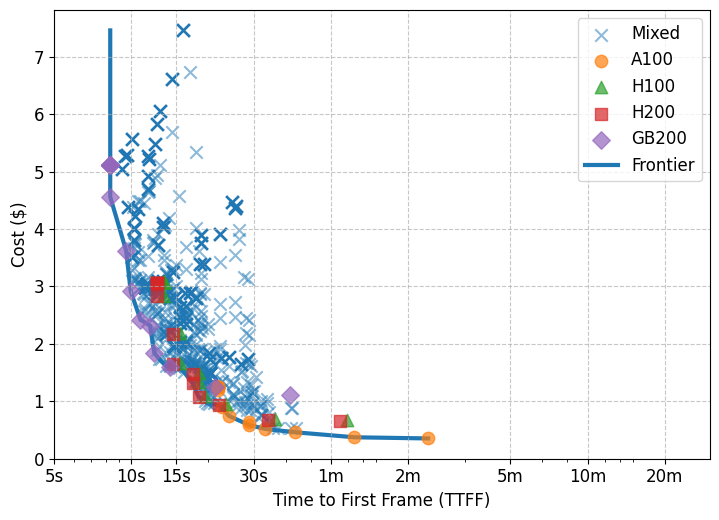

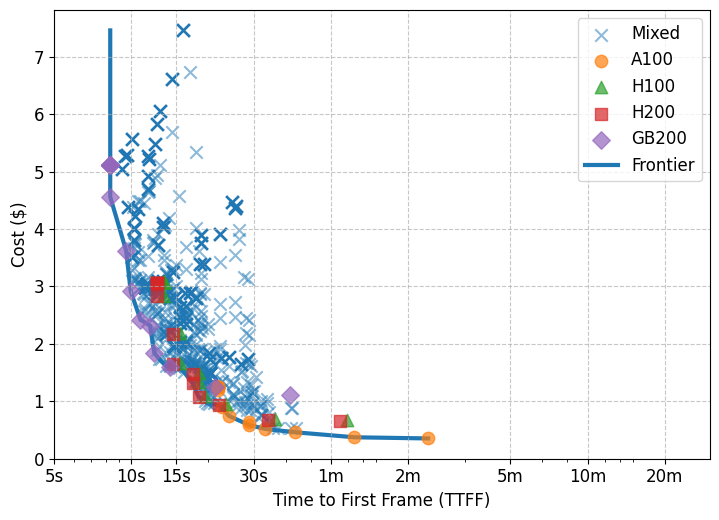

In [26]:
for policy_name in policies.keys():
    plot_ttff_vs_cost(
        ttffs=provisioning_results[policy_name]["chat"].ttffs,
        costs=provisioning_results[policy_name]["chat"].costs,
        provisions=provisioning_results[policy_name]["chat"].actual_provision,
        xmin=5,  # 5 seconds
        xmax=0.5 * SECONDS_IN_HOUR,  # 30 minutes
    )

## Summary

In [27]:
results_workflows_dir = results_dir + "workflows/"
os.makedirs(results_workflows_dir, exist_ok=True)

for policy_name in provisioning_results.keys():
    for workflow_name in provisioning_results[policy_name].keys():
        result = provisioning_results[policy_name][workflow_name]
        result.save(f"{policy_name}_{workflow_name}", results_workflows_dir)

In [28]:
provisioning_workflows_streamwise = {
    # StreamWise
    "Chat": provisioning_results["StreamWise"]["chat"],
    "Dubbing": provisioning_results["StreamWise"]["dubbing"],
    "Editing": provisioning_results["StreamWise"]["editing"],
    "Lecture": provisioning_results["StreamWise"]["lecture"],
    "Movie": provisioning_results["StreamWise"]["movie"],
    "Short": provisioning_results["StreamWise"]["short"],
    "Slide": provisioning_results["StreamWise"]["slide"],
    "Story": provisioning_results["StreamWise"]["story"],
    "PodCast": provisioning_results["StreamWise"]["podcast"],
}
provisioning_workflows_naive = {
    # Naive
    "Chat": provisioning_results["Naive"]["chat"],
    "Dubbing": provisioning_results["Naive"]["dubbing"],
    "Editing": provisioning_results["Naive"]["editing"],
    "Lecture": provisioning_results["Naive"]["lecture"],
    "Movie": provisioning_results["Naive"]["movie"],
    "Short": provisioning_results["Naive"]["short"],
    "Slide": provisioning_results["Naive"]["slide"],
    "Story": provisioning_results["Naive"]["story"],
    "PodCast": provisioning_results["Naive"]["podcast"],
}

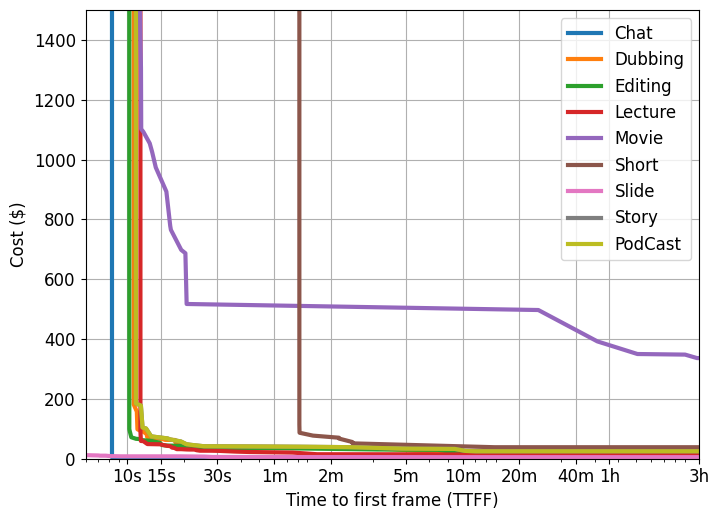

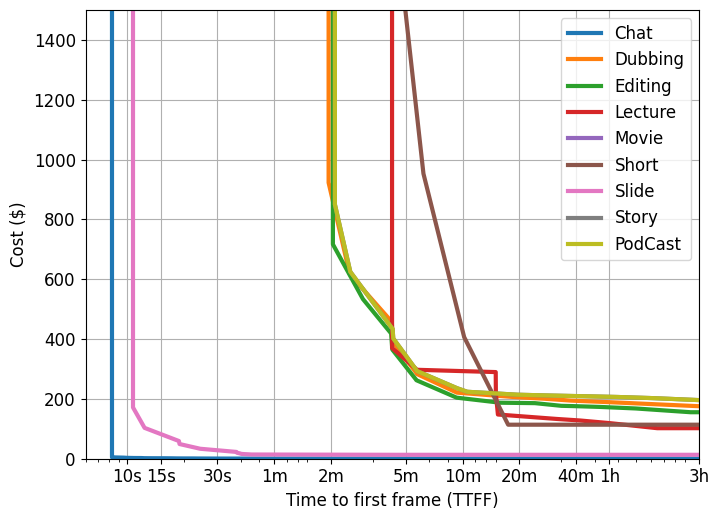

In [29]:
plot_policies_ttff_vs_cost(
    provisioning_workflows_streamwise,
    points=False,
    xmin=6,  # 6 seconds
)
plot_policies_ttff_vs_cost(
    provisioning_workflows_naive,
    points=False,
    xmin=6,  # 6 seconds
)